In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from research_utils.metrics import classif_scores
from research_utils.plot import create_panel
from research_utils.stats import cv_score, levene_test
from research_utils.dataframe import fold_scores

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
test_predictions = pd.read_parquet("../experiments/test_pred.parquet")
test_predictions.head()

,gender_true,age_true,multi_true,length_true,rf_gender_pred_label,rf_gender_pred_proba_0,rf_gender_pred_proba_1,gbm_gender_pred_label,gbm_gender_pred_proba_0,gbm_gender_pred_proba_1,...,bygender_mlp_pred_proba_1,bygender_svc_linear_pred_label,bygender_svc_linear_pred_proba_0,bygender_svc_linear_pred_proba_1,bygender_svc_poly_pred_label,bygender_svc_poly_pred_proba_0,bygender_svc_poly_pred_proba_1,bygender_svc_rbf_pred_label,bygender_svc_rbf_pred_proba_0,bygender_svc_rbf_pred_proba_1
11491,0,1,1,0,0,0.722885,0.277115,0,0.622072,0.377928,...,0.779952,1,0.302705,0.697295,1,0.356931,0.643069,1,0.407735,0.592265
8260,1,0,2,0,1,0.395532,0.604468,0,0.573884,0.426116,...,0.420765,1,0.555777,0.444223,1,0.540700,0.459300,0,0.703112,0.296888
10613,0,1,1,1,1,0.499780,0.500220,0,0.588066,0.411934,...,0.680145,1,0.272366,0.727634,1,0.348746,0.651254,1,0.279512,0.720488
2331,1,1,3,1,1,0.421016,0.578984,1,0.300303,0.699697,...,0.642105,1,0.355342,0.644658,1,0.517988,0.482012,0,0.528858,0.471142
11339,0,1,1,0,0,0.551578,0.448422,0,0.616277,0.383723,...,0.705924,1,0.255036,0.744964,1,0.361727,0.638273,1,0.266380,0.733620


In [ ]:
def get_models_scores(df, target, models):
    all_scores_list = []
    
    for col, name in models:
        model_scores = pd.DataFrame(fold_scores(classif_scores, df[target], df[col]))
        model_scores['model'] = name
        model_scores = model_scores.reset_index().rename(columns={'index': 'chunk'})
        
        all_scores_list.append(model_scores)
    
    return pd.concat(all_scores_list, axis=0, ignore_index=True)

def get_cv_by_group(scores, key):
    cv_by_key = scores.groupby(key)['accuracy'].agg(['mean', 'std'])
    cv_by_key['cv'] = cv_score(cv_by_key['std'], cv_by_key['mean'])
    return cv_by_key

def get_subsamples_cv(scores):
    return get_cv_by_group(scores, 'subsample')

def get_models_cv(scores):
    return get_cv_by_group(scores, 'model')

def get_summary(scores):
    return scores.groupby(['model', 'subsample'])[['accuracy', 'precision', 'recall', 'f1']].agg(['mean', 'std'])

def stability_plot(scores, group_scores, ax, group_key, xlabel, title):
    bars = sns.barplot(data=group_scores, x=group_key, y='mean', 
                       yerr=group_scores['std'], capsize=0.2, ax=ax,
                       color='skyblue', edgecolor='purple', 
                       error_kw={'elinewidth': 2, 'ecolor': 'darkred'})
    
    sns.stripplot(data=scores, x=group_key, y='accuracy', 
                  color='darkblue', alpha=0.5, size=3, jitter=True, ax=ax)
    
    for i, (idx, row) in enumerate(group_scores.iterrows()):
        ax.text(i, row['mean'] - row['std'] - 0.15, 
                f"CV={row['cv']:.1f}%",
                ha='center', va='bottom', fontsize=9, 
                color='darkgreen', fontweight='bold')
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Точность")
    ax.set_title(title)
    
    return ax

def get_most_stable(scores):
    stability = scores.groupby(['model', 'subsample'])['accuracy'].std().reset_index()
    stability.columns = ['model', 'subsample', 'std_accuracy']

    most_stable = stability.loc[stability.groupby('subsample')['std_accuracy'].idxmin()]
    return most_stable[['subsample', 'model', 'std_accuracy']]

def test_stability(scores):
    def levene(model):
        subgroups = [data['accuracy'].values for _, data in model.groupby('subsample')]
        return levene_test(subgroups)
    
    results = scores.groupby('model').apply(levene).reset_index()
    return results

In [ ]:
women = test_predictions[test_predictions['gender_true'] == 0]
men = test_predictions[test_predictions['gender_true'] == 1]
young = test_predictions[test_predictions['age_true'] == 0]
old = test_predictions[test_predictions['age_true'] == 1]
short = test_predictions[test_predictions['length_true'] == 0]
long = test_predictions[test_predictions['length_true'] == 1]

dfs = [
    ("all", test_predictions, len(test_predictions)),
    ("women", women, len(women)),
    ("men", men, len(men)),
    ("young", young, len(young)),
    ("old", old, len(old)),
    ("short", short, len(short)),
    ("long", long, len(long)),
]

def get_scores_by_subsamples(target, models):
    scores = []

    for name, df, _ in dfs[1:]:
        df_scores = get_models_scores(df, target, models)
        df_scores['subsample'] = name
        
        scores.append(df_scores)
        
    return pd.concat(scores, axis=0, ignore_index=True)

## Модели прогнозирования пола

In [ ]:
gender_model_columns = test_predictions.columns[test_predictions.columns.str.contains("gender_pred_label")]
gender_model_names = [ col[:-len("_gender_pred_label")] for col in gender_model_columns ]
gender_models = list(zip(gender_model_columns, gender_model_names))

gender_model_scores_df = get_scores_by_subsamples('gender_true', gender_models)
gender_model_scores_df.head()

,chunk,accuracy,precision,recall,f1,model,subsample
0,0,0.603604,1.0,0.603604,0.752809,rf,women
1,1,0.630631,1.0,0.630631,0.773481,rf,women
2,2,0.581818,1.0,0.581818,0.735632,rf,women
3,3,0.654545,1.0,0.654545,0.791209,rf,women
4,4,0.627273,1.0,0.627273,0.770950,rf,women


In [6]:
gender_summary = get_summary(gender_model_scores_df)
gender_summary

accuracy           precision              recall  \
                          mean       std      mean       std      mean   
model      subsample                                                     
gbm        long       0.641408  0.031715  0.645502  0.030536  0.641408   
           men        0.717992  0.051183  1.000000  0.000000  0.717992   
           old        0.639012  0.039707  0.652973  0.041363  0.639012   
           short      0.684663  0.053298  0.684838  0.053346  0.684663   
           women      0.598051  0.030708  1.000000  0.000000  0.598051   
           young      0.687668  0.052443  0.693866  0.050024  0.687668   
knn        long       0.618859  0.034579  0.622555  0.033226  0.618859   
           men        0.702648  0.032968  1.000000  0.000000  0.702648   
           old        0.597053  0.028223  0.613772  0.030484  0.597053   
           short      0.641536  0.039780  0.641134  0.040580  0.641536   
           women      0.544480  0.037547  1.000000  0.000000  0.544480   
           young      0.664097  0.048348  0.667483  0.051830  0.664097   
lr         long       0.633081  0.046749  0.635413  0.047127  0.633081   
           men        0.705743  0.042639  1.000000  0.000000  0.705743   
           old        0.639764  0.039126  0.651326  0.039410  0.639764   
           short      0.682135  0.042941  0.681404  0.043618  0.682135   
           women      0.600737  0.038369  1.000000  0.000000  0.600737   
           young      0.675917  0.047443  0.682749  0.047767  0.675917   
mlp        long       0.628060  0.042567  0.631316  0.043833  0.628060   
           men        0.720270  0.034244  1.000000  0.000000  0.720270   
           old        0.610209  0.035074  0.628239  0.038001  0.610209   
           short      0.659787  0.030099  0.659198  0.027186  0.659787   
           women      0.553563  0.032317  1.000000  0.000000  0.553563   
           young      0.678403  0.047500  0.681018  0.045797  0.678403   
nb         long       0.601366  0.041224  0.606088  0.042860  0.601366   
           men        0.619102  0.041443  1.000000  0.000000  0.619102   
           old        0.607736  0.017510  0.613483  0.019187  0.607736   
           short      0.639848  0.042627  0.644762  0.040367  0.639848   
           women      0.622506  0.043822  1.000000  0.000000  0.622506   
           young      0.633880  0.049639  0.664537  0.047238  0.633880   
rf         long       0.633887  0.040861  0.639722  0.039931  0.633887   
           men        0.661227  0.056707  1.000000  0.000000  0.661227   
           old        0.629949  0.027373  0.636569  0.030177  0.629949   
           short      0.660606  0.054233  0.663546  0.052828  0.660606   
           women      0.630696  0.034484  1.000000  0.000000  0.630696   
           young      0.664930  0.061700  0.685383  0.049343  0.664930   
svc_linear long       0.636415  0.043734  0.643759  0.045482  0.636415   
           men        0.642120  0.054083  1.000000  0.000000  0.642120   
           old        0.652154  0.029822  0.653044  0.031568  0.652154   
           short      0.682135  0.040202  0.685970  0.038737  0.682135   
           women      0.679648  0.034258  1.000000  0.000000  0.679648   
           young      0.666660  0.050935  0.692649  0.042218  0.666660   
svc_poly   long       0.650539  0.037790  0.657959  0.036979  0.650539   
           men        0.671286  0.030675  1.000000  0.000000  0.671286   
           old        0.656246  0.033002  0.662540  0.031714  0.656246   
           short      0.682989  0.040636  0.684849  0.040907  0.682989   
           women      0.661515  0.039084  1.000000  0.000000  0.661515   
           young      0.677577  0.040081  0.700587  0.037408  0.677577   
svc_rbf    long       0.635518  0.034829  0.641319  0.035389  0.635518   
           men        0.671309  0.045817  1.000000  0.000000  0.671309   
           old        0.659491  0.032269  0.664053  0.032658  0.659491   
           short      0.70

In [74]:
gender_models_cv = get_models_cv(gender_model_scores_df).sort_values('cv')
gender_models_cv

,mean,std,cv
model,,,
svc_poly,0.666692,0.037329,5.599088
nb,0.620740,0.041212,6.639129
svc_rbf,0.670521,0.045403,6.771354
svc_linear,0.659855,0.044831,6.794044
rf,0.646882,0.048103,7.436118
lr,0.656230,0.054287,8.272564
gbm,0.661466,0.058092,8.782245
knn,0.628112,0.061950,9.862954
mlp,0.641715,0.064273,10.015755


Анализ коэффициента вариации, позволяет ранжировать модели по стабильности, нивелируя различия в абсолютной точности. 

Наилучшую стабильность демонстрирует `svc_poly` (CV = 5.6%) - при достаточно высокой средней точности (0.667) эта модель показывает наименьшую относительную вариабельность результатов. Также высокую стабильность имеют `nb` (CV = 6.64%) и обе оставшиеся SVM-модели (`svc_rbf` и `svc_linear` с CV около 6.8%). 

Интересно, что `nb` при самой низкой средней точности (0.621) обладает вторым по величине показателем стабильности, что может быть полезно в сценариях, где важна предсказуемость, а не максимум качества.

Наименее стабильными оказались `mlp` (CV = 10.02%) и `knn` (CV = 9.86%) - их точность сильно колеблется относительно среднего уровня, причём у `mlp` это сочетается с невысокой средней точностью (0.642), что делает его наименее предпочтительным выбором с точки зрения устойчивости. 

Промежуточное положение занимают `lr`, `gbm` и `rf` (CV от 7.4% до 8.8%), которые при приемлемых средних значениях показывают умеренную, но не выдающуюся стабильность. 

<Axes: title={'center': 'Стабильность моделей'}, xlabel='Модели', ylabel='Точность'>

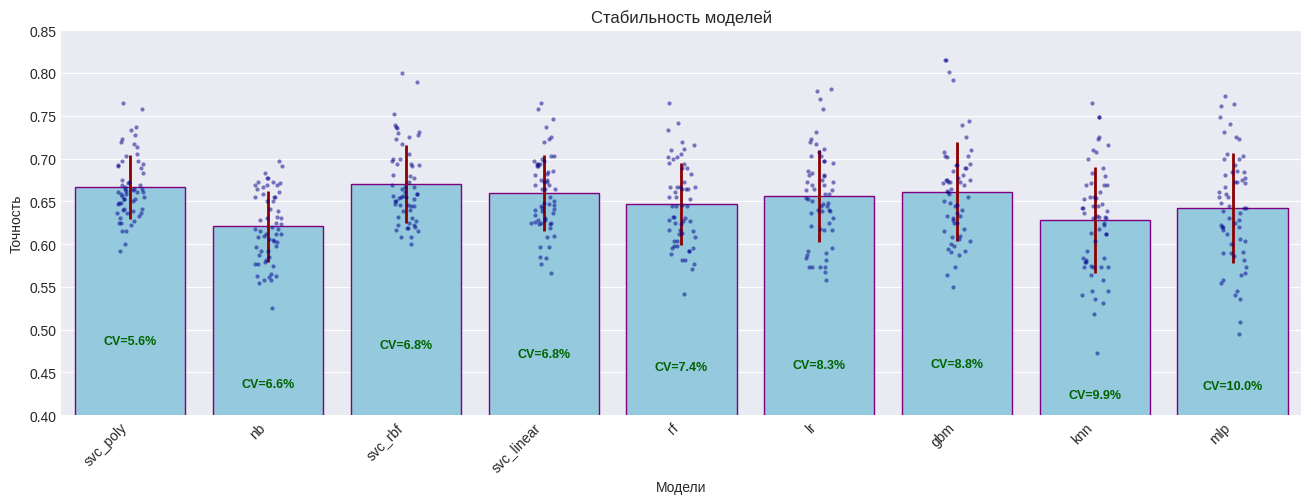

In [95]:
fix, axes = create_panel(1, cols=1)
axes.flat[0].set_ylim([0.4, 0.85])
stability_plot(gender_model_scores_df, gender_models_cv, axes.flat[0], 'model', 'Модели', 'Стабильность моделей')

In [97]:
gender_subsmaples_cv = get_subsamples_cv(gender_model_scores_df).sort_values('cv')
gender_subsmaples_cv

,mean,std,cv
subsample,,,
old,0.632402,0.037380,5.910821
long,0.631015,0.040079,6.351550
short,0.671004,0.046907,6.990516
young,0.670100,0.050348,7.513500
men,0.679077,0.053754,7.915731
women,0.617877,0.057462,9.299899


Наиболее стабильной подвыборкой оказалась группа "old" (взрослые), где относительный разброс accuracy минимален (CV = 5.91%), при этом средняя точность здесь одна из самых низких (0.632). 

Высокую стабильность демонстрирует также подвыборка "long" (длинные тексты) с CV = 6.35%. Подвыборки "short", "young" и "men" имеют умеренную относительную вариабельность (CV в диапазоне 6.99-7.92%), причём на мужчинах и молодых достигается наибольшая средняя точность (около 0.68). 

Наименее стабильной оказалась подвыборка "women" (женщины) - CV = 9.30%, что сочетается с самым низким средним значением accuracy (0.618). Таким образом, модели не только хуже распознают женщин в среднем, но и демонстрируют наибольший разброс результатов на этой группе, что указывает на повышенную сложность и неоднородность данной категории.

<Axes: title={'center': 'Стабильность подвыборок'}, xlabel='Подвыборки', ylabel='Точность'>

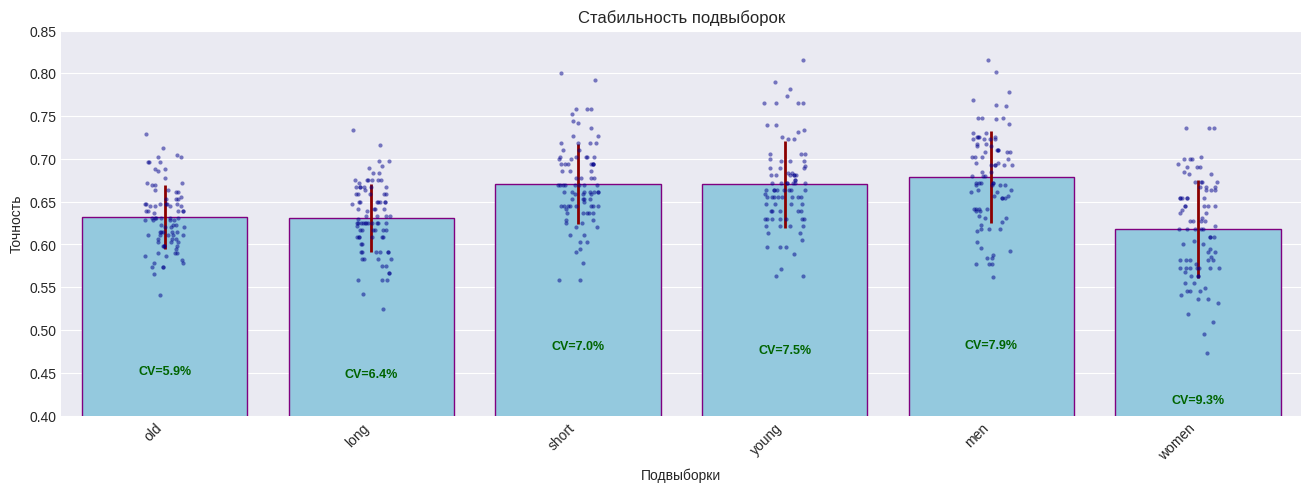

In [98]:
fix, axes = create_panel(1, cols=1)
axes.flat[0].set_ylim([0.4, 0.85])
stability_plot(gender_model_scores_df, gender_subsmaples_cv, axes.flat[0], 'subsample', 'Подвыборки', 'Стабильность подвыборок')

In [16]:
get_most_stable(gender_model_scores_df)

,subsample,model,std_accuracy
0,long,gbm,0.031715
43,men,svc_poly,0.030675
26,old,nb,0.017510
21,short,mlp,0.030099
4,women,gbm,0.030708
47,young,svc_poly,0.040081


In [ ]:
test_stability(gender_model_scores_df)

,model,p_value,levene_statistic,stability
0,gbm,0.889935,0.334397,True
1,knn,0.933416,0.258968,True
2,lr,0.946338,0.233089,True
3,mlp,0.621150,0.706394,True
4,nb,0.076572,2.122975,True
5,rf,0.291835,1.266436,True
6,svc_linear,0.879947,0.350139,True
7,svc_poly,0.980859,0.144476,True
8,svc_rbf,0.450061,0.960694,True


Тест Левене показал, что для всех моделей дисперсии accuracy значимо не различаются между подвыборками (p > 0.05), то есть относительная стабильность каждой модели сохраняется вне зависимости от демографической группы или длины текста. Это означает, что выбор модели с точки зрения стабильности может быть сделан на основе обобщённых показателей, без опасения, что на какой-то группе она окажется существенно менее надёжной.

Среди всех моделей наилучшую стабильность (минимальный коэффициент вариации) демонстрирует `svc_poly` (CV = 5.6%) при достаточно высокой средней точности (0.667). Также высокую стабильность показывают `nb` (CV = 6.64%) и остальные SVM (`svc_rbf`, `svc_linear`). При этом наименее стабильны `mlp` и `knn` (CV > 9.8%), что делает их нежелательными для применения в условиях, требующих устойчивости результатов.

Анализ по подвыборкам выявил, что наиболее сложной и нестабильной группой являются женщины (наименьшая средняя точность и наибольший CV = 9.3%), тогда как на взрослых и длинных текстах модели работают наиболее стабильно (CV ~6%). Лучшие модели для каждой подвыборки по минимуму стандартного отклонения: `gbm` (на long и women), `svc_poly` (на men и young), `nb` (на old) и `mlp` (на short). Однако, учитывая, что mlp в целом нестабилен, его лидерство на short может быть случайным; предпочтительнее использовать на short текстах, например, svc_poly, который стабилен везде.

Для практического применения наиболее сбалансированным выбором является `svc_poly`, сочетающий высокую точность и наилучшую стабильность на всех подвыборках. 

## Модели прогнозирования возрастной группы

In [ ]:
age_ind_models_columns = test_predictions.columns[test_predictions.columns.str.contains("age_pred_label")]
age_ind_model_names = [ col[:-len("_age_pred_label")] for col in age_ind_models_columns ]

age_bygender_models_columns = test_predictions.columns[test_predictions.columns.str.contains("bygender") & test_predictions.columns.str.contains("pred_label")]
age_bygender_model_names = [ col[:-len("_pred_label")] for col in age_bygender_models_columns ]

age_models = list(zip(age_ind_models_columns + age_bygender_models_columns, age_ind_model_names + age_bygender_model_names))

In [ ]:
age_model_scores_df = get_scores_by_subsamples('age_true', age_models)
age_model_scores_df.head()

,chunk,accuracy,precision,recall,f1,model,subsample
0,0,0.639640,0.644587,0.639640,0.641913,rf,women
1,1,0.522523,0.514173,0.522523,0.516311,rf,women
2,2,0.663636,0.661580,0.663636,0.662554,rf,women
3,3,0.609091,0.620047,0.609091,0.613349,rf,women
4,4,0.654545,0.654545,0.654545,0.654545,rf,women


In [25]:
age_summary = get_summary(age_model_scores_df)
age_summary

accuracy           precision              recall  \
                            mean       std      mean       std      mean   
model        subsample                                                     
bygender_gbm long       0.638053  0.034045  0.641640  0.033388  0.638053   
             men        0.615379  0.035068  0.597478  0.043333  0.615379   
             old        0.631595  0.035835  1.000000  0.000000  0.631595   
             short      0.634125  0.031094  0.638892  0.032268  0.634125   
             women      0.660647  0.048304  0.646777  0.054964  0.660647   
...                          ...       ...       ...       ...       ...   
svc_rbf      men        0.622930  0.034121  0.630775  0.032134  0.622930   
             old        0.652059  0.059394  1.000000  0.000000  0.652059   
             short      0.650689  0.034280  0.653176  0.036234  0.650689   
             women      0.670639  0.045516  0.678815  0.043209  0.670639   
             young      0.637234  0.046831  1.000000  0.000000  0.637234   

                                        f1            
                             std      mean       std  
model        subsample                                
bygender_gbm long       0.034045  0.637446  0.034904  
             men        0.035068  0.593257  0.040406  
             old        0.035835  0.773674  0.026906  
             short      0.031094  0.633647  0.031485  
             women      0.048304  0.635366  0.046583  
...                          ...       ...       ...  
svc_rbf      men        0.034121  0.624487  0.033016  
             old        0.059394  0.787984  0.043470  
             short      0.034280  0.650538  0.034687  
             women      0.045516  0.673102  0.044403  
             young      0.046831  0.777519  0.035313  

[108 rows x 8 columns]

Наиболее стабильными являются модели `bygender_lr` и `bygender_gbm`: их стандартное отклонение на большинстве подвыборок не превышает 0.04, а на ключевых группах (мужчины, женщины) часто находится в диапазоне 0.025–0.035. 

Также относительно низкую вариативность демонстрируют `svc_poly` и `bygender_svc_poly`. 

Напротив, наименее стабильными оказались `rf`, `nb` и `svc_rbf`: у них зафиксированы максимальные значения std (до 0.064 на подвыборке `young` у `rf`, 0.059 на `old` у `svc_rbf` и 0.056 на young у `nb`). 

В целом стабильность моделей заметно различается в зависимости от подвыборки: наибольший разброс наблюдается на группах young и old, что указывает на повышенную чувствительность моделей к возрастным характеристикам, тогда как на подвыборках по длине текста (short/long) вариативность выражена слабее.

In [28]:
age_models_cv = get_models_cv(age_model_scores_df).sort_values('cv')
age_models_cv

,mean,std,cv
model,,,
bygender_gbm,0.636738,0.038019,5.970849
bygender_svc_rbf,0.651604,0.040544,6.222146
bygender_lr,0.635255,0.039725,6.253452
bygender_mlp,0.626647,0.041171,6.570043
bygender_rf,0.619345,0.040796,6.586898
knn,0.611483,0.042022,6.872075
svc_poly,0.629285,0.043502,6.912995
svc_linear,0.613649,0.042916,6.993538
nb,0.583457,0.041137,7.050567


<Axes: title={'center': 'Стабильность моделей'}, xlabel='Модели', ylabel='Точность'>

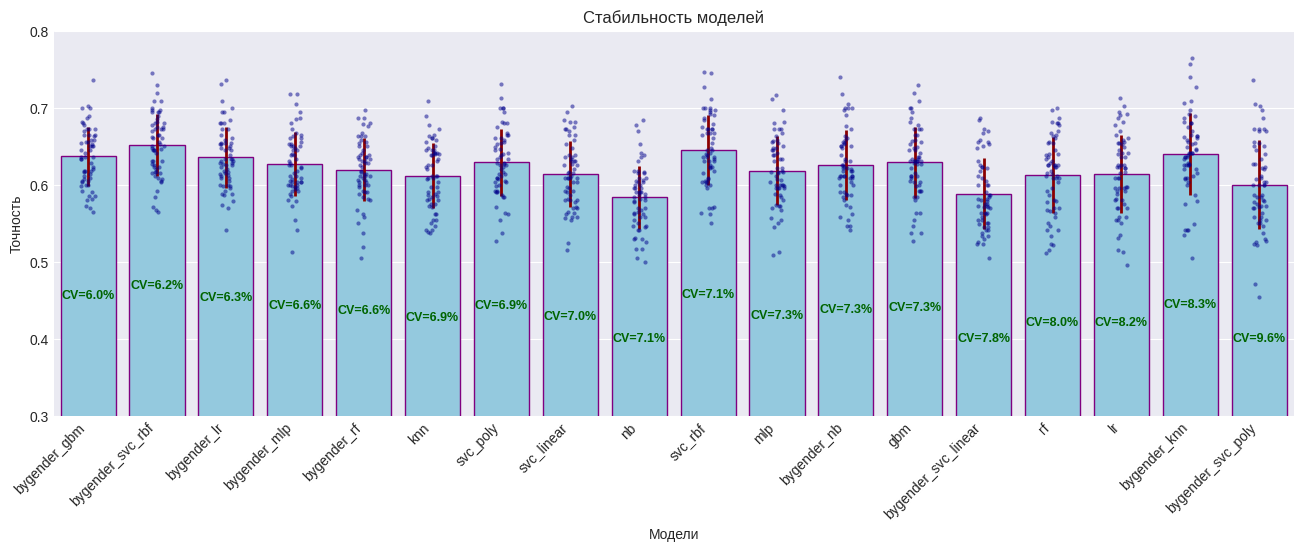

In [30]:
fix, axes = create_panel(1, cols=1)
axes.flat[0].set_ylim([0.3, 0.8])
stability_plot(age_model_scores_df, age_models_cv, axes.flat[0], 'model', 'Модели', 'Стабильность моделей')

Анализ коэффициента вариации (CV), отражающего относительный разброс accuracy по всем подвыборкам, показывает, что наиболее стабильными моделями являются `bygender_gbm` (CV = 5.97%), `bygender_svc_rbf` (6.22%) и `bygender_lr` (6.25%). Эти модели демонстрируют наименьшую вариабельность точности относительно своего среднего уровня, что свидетельствует об их устойчивости к изменению состава выборки. 

Напротив, наибольшая нестабильность наблюдается у моделей `bygender_svc_poly` (9.59%), `bygender_knn` (8.26%) и стандартных `lr` (8.23%) и `rf` (8.03%). 

В целом модели, обученные с учётом пола (bygender), показывают несколько лучшую стабильность, однако это справедливо не для всех: например, обычная `knn` (6.87%) заметно стабильнее своей специализированной версии `bygender_knn` (8.26%). 

In [31]:
age_subsmaples_cv = get_subsamples_cv(age_model_scores_df).sort_values('cv')
age_subsmaples_cv

,mean,std,cv
subsample,,,
long,0.614923,0.040968,6.662294
men,0.603054,0.040623,6.736202
women,0.641284,0.045373,7.075384
short,0.626137,0.045627,7.287086
old,0.620496,0.048980,7.893699
young,0.620545,0.057766,9.308945


<Axes: title={'center': 'Стабильность подвыборок'}, xlabel='Подвыборки', ylabel='Точность'>

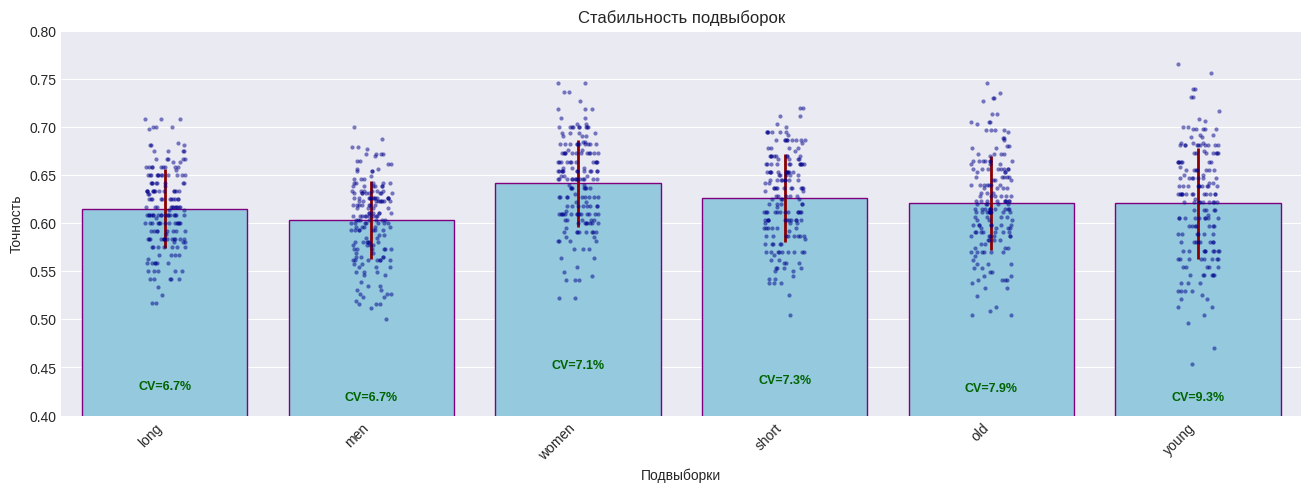

In [33]:
fix, axes = create_panel(1, cols=1)
axes.flat[0].set_ylim([0.4, 0.80])
stability_plot(age_model_scores_df, age_subsmaples_cv, axes.flat[0], 'subsample', 'Подвыборки', 'Стабильность подвыборок')

Анализ CV в разрезе подвыборок показывает, что модели демонстрируют наиболее стабильную работу на длинных текстах (CV=6.66%) и среди мужчин (6.74%), где разброс точности минимален. 

Несколько выше относительная вариативность наблюдается на женщинах (7.08%) и коротких текстах (7.29%), что указывает на умеренную нестабильность. 

Наибольший разброс accuracy зафиксирован на подвыборках взрослых (old, 7.89%) и особенно молодых (young, 9.31%), что свидетельствует о существенно более низкой стабильности моделей при работе с этими возрастными группами. 

In [34]:
get_most_stable(age_model_scores_df)

,subsample,model,std_accuracy
12,long,bygender_lr,0.026377
19,men,bygender_mlp,0.022821
80,old,nb,0.027229
51,short,bygender_svc_rbf,0.029397
82,women,nb,0.024300
5,young,bygender_gbm,0.036119


In [ ]:
test_stability(age_model_scores_df)

,model,p_value,levene_statistic,stability
0,bygender_gbm,0.671722,0.637872,True
1,bygender_knn,0.541898,0.818456,True
2,bygender_lr,0.582236,0.760508,True
3,bygender_mlp,0.538846,0.822934,True
4,bygender_nb,0.799709,0.466182,True
5,bygender_rf,0.775755,0.498807,True
6,bygender_svc_linear,0.854840,0.388087,True
7,bygender_svc_poly,0.818302,0.440421,True
8,bygender_svc_rbf,0.843918,0.404026,True
9,gbm,0.994967,0.080673,True


Тест Левене показал, что для каждой модели дисперсии accuracy значимо не различаются между подвыборками (все p>0.05), то есть стабильность каждой модели однородна на всех группах. 

Наиболее стабильными (наименьший коэффициент вариации accuracy) являются модели, обученные с учётом пола: **bygender_gbm** (CV=5.97%), **bygender_svc_rbf** (6.22%) и **bygender_lr** (6.25%). 

Для практического применения предпочтительны модели **bygender_gbm**, **bygender_svc_rbf** и **bygender_lr** как обеспечивающие наилучшее сочетание стабильности и точности

## Плоский подход


In [ ]:
flat_model_columns = test_predictions.columns[test_predictions.columns.str.contains("flat_pred_label")]
flat_model_names = [ col[:-len("_flat_pred_label")] for col in flat_model_columns ]
flat_models = list(zip(flat_model_columns, flat_model_names))

flat_model_scores_df = get_scores_by_subsamples('multi_true', flat_models)
flat_model_scores_df.head()

,chunk,accuracy,precision,recall,f1,model,subsample
0,0,0.459459,0.675074,0.459459,0.531358,rf,women
1,1,0.387387,0.606178,0.387387,0.464600,rf,women
2,2,0.381818,0.609455,0.381818,0.464505,rf,women
3,3,0.454545,0.698937,0.454545,0.549250,rf,women
4,4,0.463636,0.685375,0.463636,0.553035,rf,women


In [6]:
flat_summary = get_summary(flat_model_scores_df)
flat_summary

accuracy           precision              recall  \
                          mean       std      mean       std      mean   
model      subsample                                                     
gbm        long       0.423704  0.022522  0.407170  0.056616  0.423704   
           men        0.449783  0.029260  0.625593  0.057090  0.449783   
           old        0.421027  0.040936  0.665351  0.061160  0.421027   
           short      0.457831  0.038508  0.447901  0.047495  0.457831   
           women      0.430131  0.051075  0.683888  0.090317  0.430131   
           young      0.460931  0.041838  0.708137  0.083065  0.460931   
knn        long       0.410357  0.023457  0.358204  0.083058  0.410357   
           men        0.434486  0.045042  0.615017  0.055718  0.434486   
           old        0.369266  0.039369  0.664121  0.129449  0.369266   
           short      0.428010  0.054962  0.452248  0.061254  0.428010   
           women      0.401147  0.032914  0.724848  0.107683  0.401147   
           young      0.470154  0.060080  0.725225  0.095358  0.470154   
lr         long       0.426232  0.041085  0.395498  0.042801  0.426232   
           men        0.429865  0.041052  0.586489  0.055608  0.429865   
           old        0.416942  0.034568  0.651206  0.043543  0.416942   
           short      0.444580  0.038087  0.430704  0.049614  0.444580   
           women      0.441957  0.053973  0.687896  0.089488  0.441957   
           young      0.454223  0.054051  0.702296  0.086438  0.454223   
mlp        long       0.428739  0.037376  0.382583  0.049858  0.428739   
           men        0.455197  0.046307  0.575572  0.058487  0.455197   
           old        0.376643  0.037261  0.673857  0.090013  0.376643   
           short      0.435448  0.045949  0.435200  0.081999  0.435448   
           women      0.404742  0.030648  0.685854  0.110562  0.404742   
           young      0.488676  0.057197  0.676073  0.134408  0.488676   
nb         long       0.397024  0.030867  0.366595  0.066764  0.397024   
           men        0.402214  0.042169  0.606472  0.055767  0.402214   
           old        0.365127  0.016345  0.611978  0.082971  0.365127   
           short      0.413857  0.045245  0.403359  0.049589  0.413857   
           women      0.409214  0.031809  0.651615  0.048661  0.409214   
           young      0.446618  0.054284  0.704158  0.071528  0.446618   
rf         long       0.409538  0.028673  0.397009  0.033695  0.409538   
           men        0.401497  0.045683  0.612225  0.045550  0.401497   
           old        0.396383  0.039156  0.661951  0.058183  0.396383   
           short      0.424697  0.053034  0.422432  0.057213  0.424697   
           women      0.435594  0.037287  0.646287  0.037200  0.435594   
           young      0.438242  0.055539  0.680825  0.059924  0.438242   
svc_linear long       0.376961  0.042984  0.393548  0.035554  0.376961   
           men        0.362402  0.043477  0.601063  0.050449  0.362402   
           old        0.380768  0.042613  0.633191  0.043973  0.380768   
           short      0.404759  0.058852  0.421206  0.052498  0.404759   
           women      0.424644  0.043773  0.639691  0.052015  0.424644   
           young      0.401268  0.052763  0.681283  0.067931  0.401268   
svc_poly   long       0.387794  0.033729  0.416277  0.034485  0.387794   
           men        0.376230  0.034448  0.625681  0.056202  0.376230   
           old        0.370858  0.043340  0.656323  0.059846  0.370858   
           short      0.413933  0.028772  0.458556  0.032675  0.413933   
           women      0.430188  0.034285  0.680866  0.040270  0.430188   
           young      0.431583  0.036492  0.715039  0.053258  0.431583   
svc_rbf    long       0.433718  0.038386  0.410698  0.069452  0.433718   
           men        0.475825  0.032952  0.629835  0.033072  0.475825   
           old        0.395583  0.033186  0.677852  0.057346  0.395583   
           short      0.46

Наименьший разброс accuracy демонстрирует `nb`, особенно на подвыборке "old", где стандартное отклонение составляет всего 0.016 при средней точности 0.365. 

Также высокую стабильность показывает `svc_poly` на подвыборке "short" (std = 0.029) и `lr` на подвыборке "old" (std = 0.035). 

Наименее стабильной оказалась модель `knn`, демонстрирующая наибольший разброс точности на большинстве подвыборок, особенно на "young" (std = 0.060) и "short" (std = 0.055), что указывает на высокую чувствительность модели к вариациям в данных.

`svc_rbf` обладает умеренной стабильностью (std = 0.047%), что делает его хорошим кандидатом при балансе точности и стабильности.

In [38]:
flat_models_cv = get_models_cv(flat_model_scores_df).sort_values('cv')
flat_models_cv

,mean,std,cv
model,,,
gbm,0.440568,0.040265,9.139426
lr,0.435633,0.044350,10.180476
svc_poly,0.401764,0.042048,10.465809
rf,0.417658,0.045345,10.857018
nb,0.405675,0.044322,10.925447
svc_rbf,0.449758,0.052682,11.713304
knn,0.418903,0.052824,12.609984
mlp,0.431574,0.054781,12.693335
svc_linear,0.391800,0.050233,12.821153


Наиболее стабильной моделью является `gbm` с наименьшим коэффициентом вариации (9.14%), что свидетельствует о минимальном разбросе точности при варьировании данных. 

Также высокую стабильность демонстрируют логистическая регрессия (lr) и SVM с полиномиальным ядром (svc_poly) с CV около 10.2–10.5%.

Наименее стабильными оказались MLP, kNN и линейный SVM (CV > 12.6%), причём линейный SVM показывает самый высокий разброс (12.82%) при самой низкой средней точности. 

Модели с высоким CV могут давать непредсказуемые результаты на новых данных.

<Axes: title={'center': 'Стабильность моделей'}, xlabel='Модели', ylabel='Точность'>

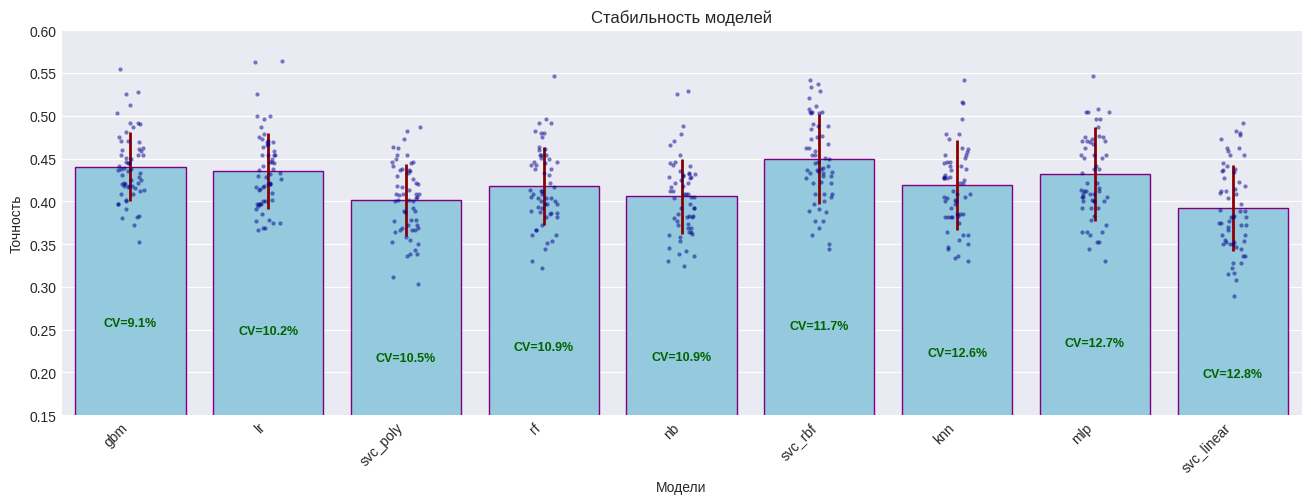

In [40]:
fix, axes = create_panel(1, cols=1)
axes.flat[0].set_ylim([0.15, 0.6])
stability_plot(flat_model_scores_df, flat_models_cv, axes.flat[0], 'model', 'Модели', 'Стабильность моделей')

In [41]:
flat_subsmaples_cv = get_subsamples_cv(flat_model_scores_df).sort_values('cv')
flat_subsmaples_cv

,mean,std,cv
subsample,,,
long,0.410452,0.037409,9.114142
women,0.421982,0.040300,9.550131
old,0.388066,0.040461,10.426192
short,0.432227,0.048346,11.185316
men,0.420833,0.052685,12.519103
young,0.455330,0.057387,12.603420


<Axes: title={'center': 'Стабильность подвыборок'}, xlabel='Подвыборки', ylabel='Точность'>

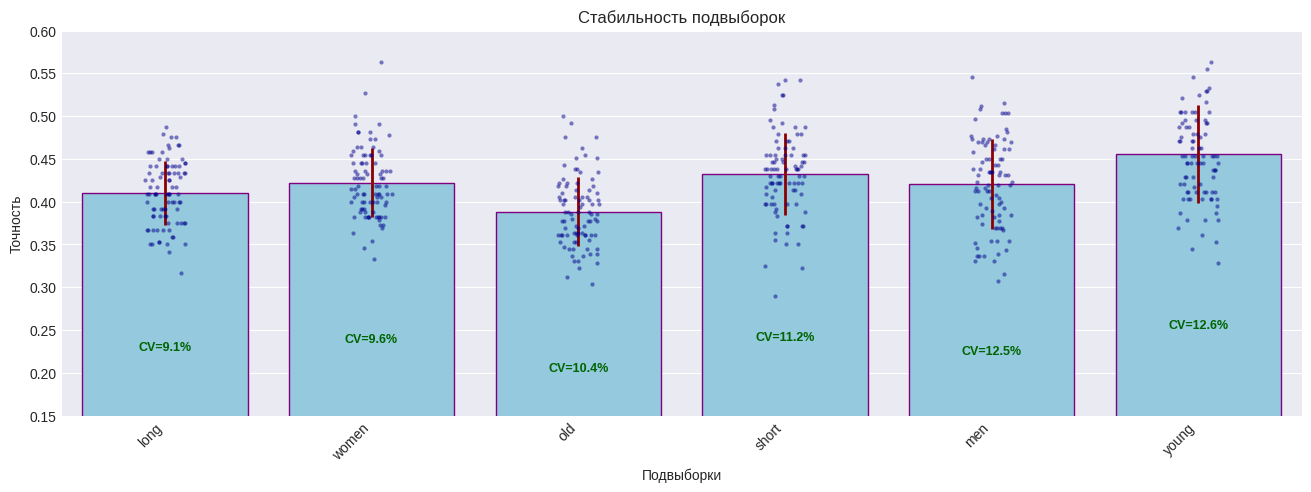

In [42]:
fix, axes = create_panel(1, cols=1)
axes.flat[0].set_ylim([0.15, 0.6])
stability_plot(flat_model_scores_df, flat_subsmaples_cv, axes.flat[0], 'subsample', 'Подвыборки', 'Стабильность подвыборок')

Наиболее стабильные предсказания наблюдаются на подвыборках с длинными текстами (long, CV = 9.11%) и на женщинах (women, CV = 9.55%). Это указывает на то, что модели демонстрируют наименьший разброс точности при работе с длинными текстами и при классификации женской аудитории. Подвыборка пожилых (old) также показывает относительно невысокую вариативность (CV = 10.43%), хотя средняя точность на ней самая низкая.

Наименьшая стабильность зафиксирована на подвыборках молодых (young, CV = 12.60%) и мужчин (men, CV = 12.52%). При этом на молодых достигается самая высокая средняя точность (0.455), но ценой значительного разброса результатов, что говорит о высокой чувствительности моделей к особенностям данных этой группы. Короткие тексты (short) также характеризуются повышенной нестабильностью (CV = 11.19%). 

Таким образом, модели более надёжны на длинных текстах и женщинах

In [44]:
get_most_stable(flat_model_scores_df)

,subsample,model,std_accuracy
0,long,gbm,0.022522
1,men,gbm,0.029260
26,old,nb,0.016345
45,short,svc_poly,0.028772
22,women,mlp,0.030648
47,young,svc_poly,0.036492


In [ ]:
test_stability(flat_model_scores_df)

,model,p_value,levene_statistic,stability
0,gbm,0.499171,0.882548,True
1,knn,0.285610,1.281033,True
2,lr,0.765059,0.513226,True
3,mlp,0.865727,0.371881,True
4,nb,0.082903,2.073698,True
5,rf,0.562255,0.788942,True
6,svc_linear,0.824938,0.431106,True
7,svc_poly,0.749488,0.534108,True
8,svc_rbf,0.961145,0.199885,True


Все рассмотренные модели обладают однородной дисперсией точности. Тест Левене не выявил статистически значимых различий в разбросе accuracy между подвыборками ни для одной из моделей (p > 0.05). Это означает, что стабильность каждой модели является её внутренним свойством и не зависит от демографических или текстовых характеристик данных: если модель показывает малый разброс на одной группе, она будет столь же стабильна и на других.

Наиболее стабильной моделью в целом является Gradient Boosting (gbm), который также лидирует по стабильности на подвыборках длинных текстов и мужчин. 

## Модели для каскадного подхода

Для каскадного подхода оптимальным выбором является комбинация моделей, демонстрирующих наилучшую стабильность и высокую точность на соответствующих этапах. 

Для первого этапа оптимальным выбором является `svc_poly`, который демонстрирует наименьший коэффициент вариации (5.6%) при достаточно высокой средней точности (0.667). В качестве альтернативы, если требуется максимальная стабильность даже ценой точности, можно использовать `nb` (CV=6.64%).

Для второго этапа наилучшую стабильность показывают модели, обученные с учётом пола:
- `bygender_gbm` (CV=5.97%),
- `bygender_svc_rbf` (CV=6.22%),
- `bygender_lr` (CV=6.25%).
Эти модели обеспечивают минимальный разброс accuracy на всех подвыборках и могут быть надёжно использованы для предсказания возраста отдельно у мужчин и женщин.

Таким образом, предлагаются следующие четыре комбинации для каскадного подхода:
- `svc_poly` + `bygender_gbm`
- `svc_poly` + `bygender_svc_rbf`
- `svc_poly` + `bygender_lr`
- `nb` + `bygender_gbm`